In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Extracting the Qualifying times for the drives
qualifying_2026 = pd.DataFrame({
    "Driver": [
        "RUS", "ANT", "HAD", "LEC", "PIA", "NOR", "HAM",
        "LAW", "LIN", "BOR", "HUL", "BEA", "OCO", "GAS",
        "ALB", "COL", "ALO", "PER", "BOT", "VER", "SAI", "STR"
    ],
    "QualifyingTime (s)": [
        78.518,   # RUS  P1  pole
        78.811,   # ANT  P2  +0.293
        79.303,   # HAD  P3  +0.785
        79.327,   # LEC  P4  +0.809
        79.380,   # PIA  P5  +0.862
        79.475,   # NOR  P6  +0.957
        79.478,   # HAM  P7  +0.960
        79.994,   # LAW  P8  +1.476
        81.247,   # LIN  P9  +2.729
        80.221,   # BOR  P10
        80.303,   # HUL  P11
        80.311,   # BEA  P12
        80.491,   # OCO  P13
        80.501,   # GAS  P14
        80.941,   # ALB  P15
        81.270,   # COL  P16
        81.969,   # ALO  P17
        82.605,   # PER  P18
        83.244,   # BOT  P19
        82.500,   # VER  P20 
        83.000,   # SAI  P21 
        85.000,   # STR  P22
    ],
    "GridPosition": list(range(1, 23))
})

In [3]:
# Extracting the team points
team_points_2025 = {
    "McLaren":       800,   
    "Mercedes":      459,
    "Red Bull":      426,
    "Ferrari":       382,
    "Williams":      137,
    "Aston Martin":   80,
    "Haas":           73,
    "Racing Bulls":   92,
    "Audi":           68,   
    "Alpine":         22,
    "Cadillac":        5,   
}
max_pts = max(team_points_2025.values())
team_performance_score = {t: p / max_pts for t, p in team_points_2025.items()}

In [4]:
# Mapping the drivers to their respective teams
driver_to_team = {
    "RUS": "Mercedes",  "ANT": "Mercedes",
    "VER": "Red Bull",  "HAD": "Red Bull",
    "LEC": "Ferrari",   "HAM": "Ferrari",
    "NOR": "McLaren",   "PIA": "McLaren",
    "ALB": "Williams",  "SAI": "Williams",
    "ALO": "Aston Martin", "STR": "Aston Martin",
    "BEA": "Haas",      "OCO": "Haas",
    "LAW": "Racing Bulls", "LIN": "Racing Bulls",
    "HUL": "Audi",      "BOR": "Audi",
    "GAS": "Alpine",    "COL": "Alpine",
    "PER": "Cadillac",  "BOT": "Cadillac",
}

qualifying_2026["Team"] = qualifying_2026["Driver"].map(driver_to_team)
qualifying_2026["TeamPerformanceScore"] = qualifying_2026["Team"].map(team_performance_score)

In [5]:
# Incorporating the regulation boost changes
reg_change_boost = {
    "Mercedes":      1.15,  
    "Ferrari":       1.05,   
    "Red Bull":      0.95,   
    "McLaren":       1.00,   
    "Williams":      0.80,
    "Aston Martin":  0.70,   
    "Haas":          0.85,
    "Racing Bulls":  0.88,
    "Audi":          0.83,
    "Alpine":        0.80,
    "Cadillac":      0.70,
}
qualifying_2026["RegChangeBoost"] = qualifying_2026["Team"].map(reg_change_boost)
qualifying_2026["AdjustedTeamScore"] = (
    qualifying_2026["TeamPerformanceScore"] * qualifying_2026["RegChangeBoost"]
)


In [6]:
# Rainfall and temperature conditions
rain_probability = 0.15
temperature = 22.0
qualifying_2026["RainProbability"] = rain_probability
qualifying_2026["Temperature"] = temperature

In [7]:
# Adding the grid penalty feature to convert it to a time disadvantage
qualifying_2026["GridPenalty (s)"] = (qualifying_2026["GridPosition"] - 1) * 0.15
pole_time = qualifying_2026["QualifyingTime (s)"].min()
qualifying_2026["GapFromPole (s)"] = qualifying_2026["QualifyingTime (s)"] - pole_time

In [8]:
# Estimating qualifying times to race conditions. 1.055 means race laps are estimated to be ~5.5% slower than qualifying laps.
# since cars carry fuel, manage tires, and deal with traffic therefore slower lap times.
QUALI_TO_RACE_FACTOR = 1.055
merged = qualifying_2026.copy()
merged["TargetLapTime (s)"] = merged["QualifyingTime (s)"] * QUALI_TO_RACE_FACTOR

In [9]:
merged.head()

,Driver,QualifyingTime (s),GridPosition,Team,TeamPerformanceScore,RegChangeBoost,AdjustedTeamScore,RainProbability,Temperature,GridPenalty (s),GapFromPole (s),TargetLapTime (s)
0,RUS,78.518,1,Mercedes,0.57375,1.15,0.659812,0.15,22.0,0.00,0.000,82.836490
1,ANT,78.811,2,Mercedes,0.57375,1.15,0.659812,0.15,22.0,0.15,0.293,83.145605
2,HAD,79.303,3,Red Bull,0.53250,0.95,0.505875,0.15,22.0,0.30,0.785,83.664665
3,LEC,79.327,4,Ferrari,0.47750,1.05,0.501375,0.15,22.0,0.45,0.809,83.689985
4,PIA,79.380,5,McLaren,1.00000,1.00,1.000000,0.15,22.0,0.60,0.862,83.745900


In [10]:
# Feature engineering
feature_cols = [
    "QualifyingTime (s)",    # strong positive correlation with race time
    "GapFromPole (s)",       # gap to pole, reinforces qualifying hierarchy
    "AdjustedTeamScore",     # team strength (higher = better), negative constraint
    "GridPenalty (s)",       # grid spot penalty
    "RainProbability",       # weather
    "Temperature",           # weather
]

X = merged[feature_cols].copy()
y = merged["TargetLapTime (s)"].copy()

In [11]:
# Filling in the missing values 
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

In [12]:
# Feature scaling - Since qualifying time and gap to pole are dominanat they should dominate oter features
QUALI_SCALE = 3.0
X_scaled = X_imputed.copy()
X_scaled[:, 0] *= QUALI_SCALE   
X_scaled[:, 1] *= QUALI_SCALE   

In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42
)

In [14]:
# The XGBoost Model
model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=0.5,       
    max_delta_step=1,      
    random_state=42,
    monotone_constraints=(1, 1, -1, 1, 1, 0),  
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
merged["PredictedRaceTime (s)"] = model.predict(X_scaled)

final_results = merged.sort_values(
    by=["PredictedRaceTime (s)", "GridPosition"]
).reset_index(drop=True)

In [15]:
# Printing final results
podium = final_results.head(3)
print("\n" + "="*65)
print("   🏆  PREDICTED PODIUM — 2026 AUSTRALIAN GRAND PRIX")
print("="*65)
print(f"  🥇  P1: {podium.iloc[0]['Driver']} ({podium.iloc[0]['Team']})")
print(f"  🥈  P2: {podium.iloc[1]['Driver']} ({podium.iloc[1]['Team']})")
print(f"  🥉  P3: {podium.iloc[2]['Driver']} ({podium.iloc[2]['Team']})")


   🏆  PREDICTED PODIUM — 2026 AUSTRALIAN GRAND PRIX
  🥇  P1: RUS (Mercedes)
  🥈  P2: ANT (Mercedes)
  🥉  P3: HAD (Red Bull)


In [16]:
# Model evaluation - Mean absolute error
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"\n  Model MAE (test set): {mae:.3f} seconds")
print("="*65)


  Model MAE (test set): 0.425 seconds


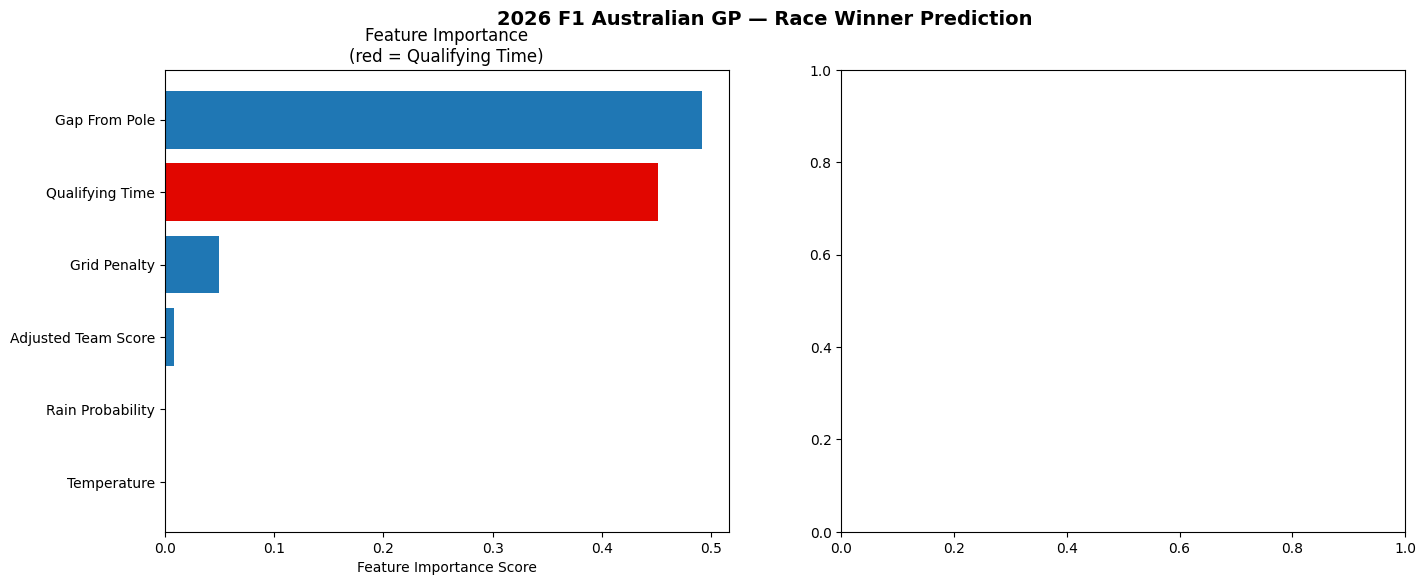

In [17]:
#Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("2026 F1 Australian GP — Race Winner Prediction", fontsize=14, fontweight="bold")

importance = model.feature_importances_
feature_labels = [
    "Qualifying Time",
    "Gap From Pole",
    "Adjusted Team Score",
    "Grid Penalty",
    "Rain Probability",
    "Temperature",
]
sorted_idx = np.argsort(importance)
colors = ["#e10600" if f == "Qualifying Time" else "#1f77b4" for f in [feature_labels[i] for i in sorted_idx]]
axes[0].barh([feature_labels[i] for i in sorted_idx], importance[sorted_idx], color=colors)
axes[0].set_xlabel("Feature Importance Score")
axes[0].set_title("Feature Importance\n(red = Qualifying Time)")
axes[0].axvline(x=0, color="black", linewidth=0.5)